In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

%matplotlib inline


from lvmdap.dap_tools import list_columns,read_DAP_file,map_plot_DAP
from lvmdap.dap_tools import plot_spectra,plot_spec,read_tab_EL
from lvmdap.dap_tools import read_coeffs_RSP
from matplotlib import use as mpl_use
from astropy.io import fits, ascii
from astropy.table import Table, join,QTable
from astropy.table import unique as tab_unique
from astropy.cosmology import WMAP9 as cosmo
#mpl_use('Agg')

%matplotlib inline
from matplotlib import rcParams as rc
rc.update({'font.size': 19,\
           'font.weight': 900,\
           'text.usetex': True,\
           'path.simplify'           :   True,\
           'xtick.labelsize' : 19,\
           'ytick.labelsize' : 19,\
#           'xtick.major.size' : 3.5,\
#           'ytick.major.size' : 3.5,\
           'axes.linewidth'  : 2.0,\
               # Increase the tick-mark lengths (defaults are 4 and 2)
           'xtick.major.size'        :   6,\
           'ytick.major.size'        :   6,\
           'xtick.minor.size'        :   3,\
           'ytick.minor.size'        :   3,\
           'xtick.major.width'       :   1,\
           'ytick.major.width'       :   1,\
           'lines.markeredgewidth'   :   1,\
           'legend.numpoints'        :   1,\
           'xtick.minor.width'       :   1,\
           'ytick.minor.width'       :   1,\
           'legend.frameon'          :   False,\
           'legend.handletextpad'    :   0.3,\
           'font.family'    :   'serif',\
           'mathtext.fontset'        :   'stix',\
           'axes.facecolor' : "w",\
           
          })



In [3]:
DIR='/disk-a/sanchez/LVM/LVM/ver_231113/output_dap/'
label='m_int_test'
out_file_fit=f'{DIR}/{label}.output.fits'
out_file_ps=f'{DIR}/{label}.rsp.txt'
out_file_coeffs=f'{DIR}/{label}.coeffs.txt'
output_path='figs/'
outfile='test.pdf'
tab_el=read_tab_EL('_legacy/emission_lines_long_list.LVM')
tab_coeffs=read_coeffs_RSP(coeffs_file=out_file_coeffs)

rsp_file='/disk-a/sanchez/LVM/LVM/ver_231113/mstar-stlib-cl-108.fits.gz'
rsp_hdu=fits.open(rsp_file)
rsp_hdu.info()


Filename: /disk-a/sanchez/LVM/LVM/ver_231113/mstar-stlib-cl-108.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SPECTRA       1 PrimaryHDU      13   (6351, 108)   float32   
  1  PARAMETERS    1 BinTableHDU     29   108R x 10C   [D, E, E, E, E, E, E, E, E, E]   
  2  ERROR         1 ImageHDU        14   (6351, 108)   float32   
  3  ORG_PARAM     1 BinTableHDU     31   1235R x 11C   [K, E, E, E, E, E, E, E, E, E, J]   
  4  PDF_TEFF_LOGG    1 ImageHDU        17   (100, 100, 108)   float64   
  5  PDF_TEFF_MET    1 ImageHDU        17   (100, 100, 108)   float64   
  6  PDF_TEFF_ALPHAM    1 ImageHDU        17   (100, 100, 108)   float64   
  7  PDF_MET_ALPHAM    1 ImageHDU        17   (100, 100, 108)   float64   
  8  PDF_MET_LOGG    1 ImageHDU        17   (100, 100, 108)   float64   
  9  PDF_LOGG_MET    1 ImageHDU        17   (100, 100, 108)   float64   


In [4]:
in_file="mastar-catalogue_100.fits.gz"
hdu_in=fits.open(in_file)
tab_in=Table(hdu_in[1].data)
#tab_in['TEFF']=np.log10(tab_in['TEFF'])
tab_in.columns
#plt.scatter(tab_in['TEFF'],tab_in['LOGG'])

<TableColumns names=('ID','RECORD','NEXP','RA','DEC','DIST','EBV','VCORR','SNR','FNORM','USDSS','GSDSS','RSDSS','ISDSS','ZSDSS','RADVEL','RVERR','TEFF','LOGG','MET','ALPHAM')>

In [5]:
in_file="/disk-a/sanchez/LVM/LVM/ver_231113/mstar-stlib-cl-342.fits.gz"
hdu_in=fits.open(in_file)
tab_in=Table(hdu_in[1].data)
#tab_in['TEFF']=np.log10(tab_in['TEFF'])
tab_in.columns


DIR='/disk-a/sanchez/LVM/LVM/ver_231113/output_dap/'
#label="MaStar_test"
label="test_cl_108"
out_file_fit=f'{DIR}/{label}.output.fits'
out_file_ps=f'{DIR}/{label}.rsp.txt'
out_file_coeffs=f'{DIR}/{label}.coeffs.txt'
output_path='figs/'
outfile='test.pdf'
tab_el=read_tab_EL('_legacy/emission_lines_long_list.LVM')
tab_coeffs=read_coeffs_RSP(coeffs_file=out_file_coeffs)

rsp_file='/disk-a/sanchez/LVM/LVM/ver_231113/mstar-stlib-cl-36.fits.gz'
rsp_hdu=fits.open(rsp_file)
rsp_hdu.info()


Filename: /disk-a/sanchez/LVM/LVM/ver_231113/mstar-stlib-cl-36.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SPECTRA       1 PrimaryHDU      13   (6351, 36)   float32   
  1  PARAMETERS    1 BinTableHDU     29   36R x 10C   [D, E, E, E, E, E, E, E, E, E]   
  2  ERROR         1 ImageHDU        14   (6351, 36)   float32   
  3  ORG_PARAM     1 BinTableHDU     31   1235R x 11C   [K, E, E, E, E, E, E, E, E, E, J]   
  4  PDF_TEFF_LOGG    1 ImageHDU        17   (100, 100, 36)   float64   
  5  PDF_TEFF_MET    1 ImageHDU        17   (100, 100, 36)   float64   
  6  PDF_TEFF_ALPHAM    1 ImageHDU        17   (100, 100, 36)   float64   
  7  PDF_MET_ALPHAM    1 ImageHDU        17   (100, 100, 36)   float64   
  8  PDF_MET_LOGG    1 ImageHDU        17   (100, 100, 36)   float64   
  9  PDF_LOGG_MET    1 ImageHDU        17   (100, 100, 36)   float64   


Text(0, 0.5, '[$\\alpha$/Fe]')

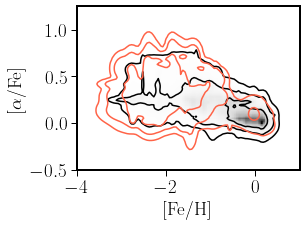

In [6]:
hdu_now=rsp_hdu['PDF_TEFF_LOGG']
xlabel=r'log(T$_{\rm eff}$)'
ylabel=r'log(g)'

hdu_now=rsp_hdu['PDF_MET_ALPHAM']
xlabel=r'[Fe/H]'
ylabel=r'[$\alpha$/Fe]'


(nz,ny,nx)=hdu_now.data.shape
xLims=(hdu_now.header['CRVAL1'],hdu_now.header['CRVAL1']+nx*hdu_now.header['CDELT1'])
yLims=(hdu_now.header['CRVAL2'],hdu_now.header['CRVAL2']+ny*hdu_now.header['CDELT2'])
extent=(xLims[0], xLims[1], yLims[0], yLims[1])
n_fib = 0
mask_fib = (tab_coeffs['id_fib']==n_fib)
tab_now=tab_coeffs[mask_fib]
den_map=np.average(hdu_now.data,axis=0)
den_map_few=np.average(hdu_now.data,weights=tab_now['COEFF'],axis=0)



conts=[0.99,0.65,0.40,0.0]
fig, ax = plt.subplots(figsize=(4,3))
ax.imshow(den_map,extent=extent,cmap='Greys',origin='lower', aspect='auto')

vals=[]
levels=[]
den_map_p = den_map/np.max(den_map)
for idx,cuts in enumerate(np.arange(0.00,1.0,0.01)):
    mask_now= den_map_p>cuts
    levels.append(cuts)
    vals.append(den_map_p[mask_now].sum()/den_map_p.sum())
vals_cont=np.array(conts)
levels_cont=np.interp(vals_cont,np.array(levels),np.array(vals))
p_cont=ax.contour(den_map_p,levels_cont,colors='k',origin='lower', extent=extent)


vals=[]
levels=[]
den_map_p = den_map_few/np.max(den_map_few)
for idx,cuts in enumerate(np.arange(0.00,1.0,0.01)):
    mask_now= den_map_p>cuts
    levels.append(cuts)
    vals.append(den_map_p[mask_now].sum()/den_map_p.sum())
vals_cont=np.array(conts)
levels_cont=np.interp(vals_cont,np.array(levels),np.array(vals))

p_cont_few=ax.contour(den_map_p,levels_cont, colors='tomato',origin='lower', extent=extent)
ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)

#print(nx,ny)

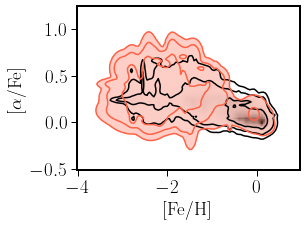

In [11]:



def get_den_levels(den_map=None):    
    vals=[]
    levels=[]
    den_map_p = den_map/np.max(den_map)
    for idx,cuts in enumerate(np.arange(0.00,1.0,0.01)):
        mask_now= den_map_p>cuts
        levels.append(cuts)
        vals.append(den_map_p[mask_now].sum()/den_map_p.sum())
    vals_cont=np.array(conts)
    levels_cont=np.interp(vals_cont,np.array(levels),np.array(vals))
    return levels_cont,den_map_p


def PDF_plot(ax=None,hdu_now=None,xlabel=None,ylabel=None,\
             n_fib=None,tab_coeffs=None,\
             conts=[0.99,0.65,0.40,0.0],color_PDF='tomato'):
    (nz,ny,nx)=hdu_now.data.shape
    xLims=(hdu_now.header['CRVAL1']-0.5*hdu_now.header['CDELT1'],\
           hdu_now.header['CRVAL1']-0.5*hdu_now.header['CDELT1']+nx*hdu_now.header['CDELT1'])
    yLims=(hdu_now.header['CRVAL2']-0.5*hdu_now.header['CDELT2'],\
           hdu_now.header['CRVAL2']-0.5*hdu_now.header['CDELT2']+ny*hdu_now.header['CDELT2'])
    extent=(xLims[0], xLims[1], yLims[0], yLims[1])
    mask_fib = (tab_coeffs['id_fib']==n_fib)
    tab_now=tab_coeffs[mask_fib]
    den_map=np.average(hdu_now.data,axis=0)
    den_map_few=np.average(hdu_now.data,weights=tab_now['COEFF'],axis=0)

    ax.imshow(den_map,extent=extent,cmap='Greys',origin='lower', aspect='auto')
    levels_cont,den_map_p=get_den_levels(den_map=den_map) 
    p_cont=ax.contour(den_map_p,levels_cont,colors='k',origin='lower', extent=extent)

    levels_cont,den_map_p=get_den_levels(den_map=den_map_few) 
    p_cont_few=ax.contour(den_map_p,levels_cont, colors=color_PDF,origin='lower', extent=extent)
    p_cont_few=ax.contourf(den_map_p,levels_cont, colors=color_PDF,origin='lower', extent=extent,alpha=0.3)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    return den_map_few


def PDF_get(ax=None,hdu_now=None,xlabel=None,ylabel=None,\
             n_fib=None,tab_coeffs=None,\
             conts=[0.99,0.65,0.40,0.0],color_PDF='tomato'):
    (nz,ny,nx)=hdu_now.data.shape
    xLims=(hdu_now.header['CRVAL1'],hdu_now.header['CRVAL1']+nx*hdu_now.header['CDELT1'])
    yLims=(hdu_now.header['CRVAL2'],hdu_now.header['CRVAL2']+ny*hdu_now.header['CDELT2'])
    extent=(xLims[0], xLims[1], yLims[0], yLims[1])
    mask_fib = (tab_coeffs['id_fib']==n_fib)
    tab_now=tab_coeffs[mask_fib]
    den_map=np.average(hdu_now.data,axis=0)
    den_map_few=np.average(hdu_now.data,weights=tab_now['COEFF'],axis=0)
    return den_map_few

hdu_now=rsp_hdu['PDF_TEFF_LOGG']
xlabel=r'log(T$_{\rm eff}$)'
ylabel=r'log(g)'

hdu_now=rsp_hdu['PDF_MET_ALPHAM']
xlabel=r'[Fe/H]'
ylabel=r'[$\alpha$/Fe]'

fig, ax = plt.subplots(figsize=(4,3))  
PDF_plot(ax=ax,hdu_now=hdu_now,xlabel=xlabel,ylabel=ylabel,\
             n_fib=0,tab_coeffs=tab_coeffs,\
             conts=[0.99,0.65,0.40,0.0])  
#print(nx,ny)


def PDF_plot_cl(ax=None,hdu_now=None,xlabel=None,ylabel=None,\
             n_fibs=None,\
             conts=[0.99,0.65,0.40,0.0],cmap='Spectral',c_cut=0.8):
    (nz,ny,nx)=hdu_now.data.shape
    xLims=(hdu_now.header['CRVAL1'],hdu_now.header['CRVAL1']+nx*hdu_now.header['CDELT1'])
    yLims=(hdu_now.header['CRVAL2'],hdu_now.header['CRVAL2']+ny*hdu_now.header['CDELT2'])
    extent=(xLims[0], xLims[1], yLims[0], yLims[1])
    

    den_map=np.average(hdu_now.data,axis=0)

    
    ax.imshow(den_map,extent=extent,cmap='Greys',origin='lower', aspect='auto')
    levels_cont,den_map_p=get_den_levels(den_map=den_map) 
    p_cont=ax.contour(den_map_p,levels_cont,colors='k',origin='lower', extent=extent)


    cmap_class = mpl.colormaps[cmap]
    colors = cmap_class(np.linspace(0, c_cut, len(n_fibs)))
    for I,n_fib in enumerate(n_fibs):
        den_map_few=hdu_now.data[n_fib,:,:]
        levels_cont,den_map_p=get_den_levels(den_map=den_map_few) 
        p_cont_few=ax.contour(den_map_p,levels_cont, colors=colors[I],origin='lower', extent=extent, label=f'\#{n_fib}')
        color_now = mpl.colors.to_hex(colors[I], keep_alpha=True)
#        print(I,colors[I])
        p_cont_few=ax.contourf(den_map_p,levels_cont, colors=color_now,origin='lower', extent=extent, alpha=0.3)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

#print(nx,ny)


0.15 0.15
0.15 0.45
0.45 0.15
0.45 0.45


<ipython-input-15-053294f31cda>:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


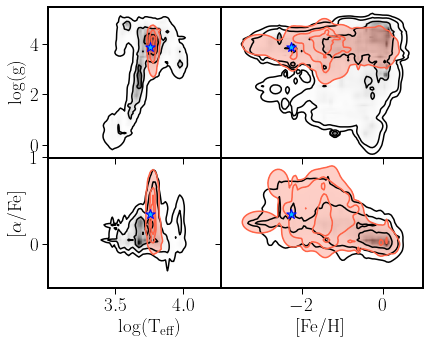

In [15]:
n_fib=1
fig=plt.figure(figsize=(8,6))
left=[0.15,0.45]
width=[0.35,0.35]
axLS=[]
for x in left:
    for y in left:
        print(x,y)
        axLS.append(fig.add_axes([x, y, 0.35, 0.35]))

axLS[1].set_xticklabels([])
axLS[2].set_yticklabels([])
axLS[3].set_xticklabels([])
axLS[3].set_yticklabels([])
#conts=[0.95,0.65,0.40,0.0]
conts=[0.99,0.65,0.35,0.0]
#conts=[0.85,0.40,0.0]



hdu_now=rsp_hdu['PDF_TEFF_LOGG']
xlabel=r'log(T$_{\rm eff}$)'
ylabel=r'log(g)'
PDF_plot(ax=axLS[1],hdu_now=hdu_now,xlabel='',ylabel=ylabel,\
             n_fib=n_fib,tab_coeffs=tab_coeffs,\
             conts=conts)  

hdu_now=rsp_hdu['PDF_TEFF_ALPHAM']
xlabel=r'log(T$_{\rm eff}$)'
ylabel=r'[$\alpha$/Fe]'
PDF_plot(ax=axLS[0],hdu_now=hdu_now,xlabel=xlabel,ylabel=ylabel,\
             n_fib=n_fib,tab_coeffs=tab_coeffs,\
             conts=conts)  


hdu_now=rsp_hdu['PDF_MET_ALPHAM']
xlabel=r'[Fe/H]'
ylabel=r'[$\alpha$/Fe]'

PDF_plot(ax=axLS[2],hdu_now=hdu_now,xlabel=xlabel,ylabel='',\
             n_fib=n_fib,tab_coeffs=tab_coeffs,\
             conts=conts)  

hdu_now=rsp_hdu['PDF_MET_LOGG']
xlabel=r'[Fe/H]'
ylabel=r'log(g)'

PDF_plot(ax=axLS[3],hdu_now=hdu_now,xlabel='',ylabel='',\
             n_fib=n_fib,tab_coeffs=tab_coeffs,\
             conts=conts)  

axLS[0].set_xlim(3.01,4.49)
axLS[1].set_xlim(3.01,4.49)

axLS[2].set_xlim(-3.99,0.99)
axLS[3].set_xlim(-3.99,0.99)

color='deepskyblue'
ecolor='blue'
size=100
axLS[1].scatter(tab_in['TEFF'][n_fib],tab_in['LOGG'][n_fib],\
                color=color,zorder=1000,marker='*',s=size,edgecolor=ecolor)
axLS[0].scatter(tab_in['TEFF'][n_fib],tab_in['ALPHAM'][n_fib],\
                color=color,zorder=1000,marker='*',s=size,edgecolor=ecolor)
axLS[2].scatter(tab_in['MET'][n_fib],tab_in['ALPHAM'][n_fib],\
                color=color,zorder=1000,marker='*',s=size,edgecolor=ecolor)
axLS[3].scatter(tab_in['MET'][n_fib],tab_in['LOGG'][n_fib],\
                color=color,zorder=1000,marker='*',s=size,edgecolor=ecolor)

#axLS[1].scatter(tab_in['TEFF'],tab_in['LOGG'],color='green')
#print(tab_in['TEFF'][n_fib],tab_in['LOGG'][n_fib])
figname=f'PDF_rsp_Mstar_{n_fib}'
fig.tight_layout()
fig.savefig('figs/rsp/'+figname+".pdf", transparent=False, facecolor='white', edgecolor='white')#.pdf")

In [128]:
print(len(tab_now))

36


In [129]:
tab_now

id_fib,rsp,TEFF,LOGG,META,ALPHAM,COEFF,Min.Coeff,log(M/L),AV,N.Coeff,Err.Coeff
int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
0,0,3.629,1.9886,-0.485,0.1096,0.0,0.0,13.0847,0.0,0.0,0.0
0,1,3.7826,4.0492,-0.5526,0.1543,0.0,0.0,13.5753,0.0,0.0,0.0
0,2,3.8086,3.4356,-1.1488,0.1889,0.0,0.0,12.5418,0.0,0.0,0.0
0,3,3.7844,3.9084,-1.6174,0.3525,0.0,0.0,14.6349,0.0,0.0,0.0
0,4,3.6633,2.6987,0.1268,0.0499,0.0,0.0,13.1411,0.0,0.0,0.0
0,5,3.8356,4.0348,-0.6166,0.1017,0.0,0.0,13.3309,0.0,0.0,0.0
0,6,3.5178,0.6087,-0.2967,0.1003,0.0,0.0,13.2847,0.0,0.0,0.0
0,7,3.8047,4.0025,-1.6012,0.3365,0.3408,0.3407,14.6054,0.0,0.3408,0.0014
0,8,3.7856,3.9399,-2.2739,0.3636,0.0002,0.0002,14.7144,0.0,0.0002,0.0


In [130]:
DIR='/disk-a/sanchez/LVM/LVM/ver_231113/output_dap/'
label='m_int_test'
out_file_fit=f'{DIR}/{label}.output.fits'
out_file_ps=f'{DIR}/{label}.rsp.txt'
out_file_coeffs=f'{DIR}/{label}.coeffs.txt'
output_path='figs/'
outfile='test.pdf'
tab_el=read_tab_EL('_legacy/emission_lines_long_list.LVM')
tab_coeffs=read_coeffs_RSP(coeffs_file=out_file_coeffs)

rsp_file='/disk-a/sanchez/LVM/LVM/ver_231113/mstar-stlib-cl-108.fits.gz'
rsp_hdu=fits.open(rsp_file)
rsp_hdu.info()



Filename: /disk-a/sanchez/LVM/LVM/ver_231113/mstar-stlib-cl-108.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SPECTRA       1 PrimaryHDU      13   (6351, 108)   float32   
  1  PARAMETERS    1 BinTableHDU     29   108R x 10C   [D, E, E, E, E, E, E, E, E, E]   
  2  ERROR         1 ImageHDU        14   (6351, 108)   float32   
  3  ORG_PARAM     1 BinTableHDU     31   1235R x 11C   [K, E, E, E, E, E, E, E, E, E, J]   
  4  PDF_TEFF_LOGG    1 ImageHDU        17   (100, 100, 108)   float64   
  5  PDF_TEFF_MET    1 ImageHDU        17   (100, 100, 108)   float64   
  6  PDF_TEFF_ALPHAM    1 ImageHDU        17   (100, 100, 108)   float64   
  7  PDF_MET_ALPHAM    1 ImageHDU        17   (100, 100, 108)   float64   
  8  PDF_MET_LOGG    1 ImageHDU        17   (100, 100, 108)   float64   
  9  PDF_LOGG_MET    1 ImageHDU        17   (100, 100, 108)   float64   


In [131]:
print(len(tab_coeffs))

108


In [132]:
#print(tab_coeffs)
tab_coeffs['COEFF']=0
#tab_coeffs['COEFF'][68]=1
n_rsp=19
tab_coeffs['COEFF'][n_rsp]=1

0.1 0.1
0.1 0.5
0.5 0.1
0.5 0.5
3.7602346 4.1419644


<ipython-input-133-65407043c39a>:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


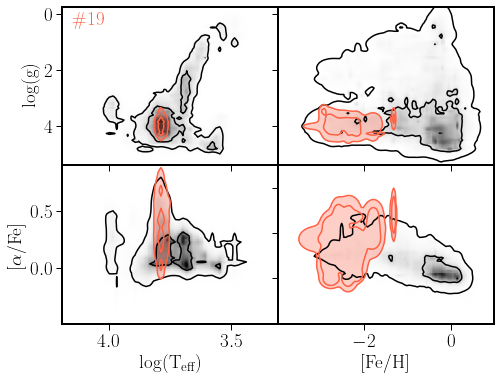

In [133]:
n_fib=0
fig=plt.figure(figsize=(7.5,5.5))
left=[0.1,0.5]
width=0.4
axLS=[]
for x in left:
    for y in left:
        print(x,y)
        axLS.append(fig.add_axes([x+0.03, y+0.05, width, width]))

axLS[1].set_xticklabels([])
axLS[2].set_yticklabels([])
axLS[3].set_xticklabels([])
axLS[3].set_yticklabels([])
#conts=[0.95,0.65,0.40,0.0]
conts=[0.85,0.40,0.0]



hdu_now=rsp_hdu['PDF_TEFF_LOGG']
xlabel=r'log(T$_{\rm eff}$)'
ylabel=r'log(g)'
PDF_plot(ax=axLS[1],hdu_now=hdu_now,xlabel='',ylabel=ylabel,\
             n_fib=n_fib,tab_coeffs=tab_coeffs,\
             conts=conts)  

hdu_now=rsp_hdu['PDF_TEFF_ALPHAM']
xlabel=r'log(T$_{\rm eff}$)'
ylabel=r'[$\alpha$/Fe]'
PDF_plot(ax=axLS[0],hdu_now=hdu_now,xlabel=xlabel,ylabel=ylabel,\
             n_fib=n_fib,tab_coeffs=tab_coeffs,\
             conts=conts)  


hdu_now=rsp_hdu['PDF_MET_ALPHAM']
xlabel=r'[Fe/H]'
ylabel=r'[$\alpha$/Fe]'

PDF_plot(ax=axLS[2],hdu_now=hdu_now,xlabel=xlabel,ylabel='',\
             n_fib=n_fib,tab_coeffs=tab_coeffs,\
             conts=conts)  

hdu_now=rsp_hdu['PDF_MET_LOGG']
xlabel=r'[Fe/H]'
ylabel=r'log(g)'

PDF_plot(ax=axLS[3],hdu_now=hdu_now,xlabel='',ylabel='',\
             n_fib=n_fib,tab_coeffs=tab_coeffs,\
             conts=conts)  

axLS[0].set_xlim(4.19,3.31)
axLS[1].set_xlim(4.19,3.31)

axLS[0].set_ylim(-0.49,0.9)
axLS[3].set_ylim(-0.49,0.9)



axLS[2].set_xlim(-3.99,0.99)
axLS[3].set_xlim(-3.99,0.99)

axLS[1].set_ylim(5.4,-0.25)
axLS[3].set_ylim(5.4,-0.25)

color='deepskyblue'
ecolor='blue'
size=100

axLS[1].text(4.15,0.4,f'\#{n_rsp}',color='tomato')
#axLS[1].scatter(tab_in['TEFF'][n_fib],tab_in['LOGG'][n_fib],\
#                color=color,zorder=1000,marker='*',s=size,edgecolor=ecolor)
#axLS[0].scatter(tab_in['TEFF'][n_fib],tab_in['ALPHAM'][n_fib],\
#                color=color,zorder=1000,marker='*',s=size,edgecolor=ecolor)
#axLS[2].scatter(tab_in['MET'][n_fib],tab_in['ALPHAM'][n_fib],\
#                color=color,zorder=1000,marker='*',s=size,edgecolor=ecolor)
#axLS[3].scatter(tab_in['MET'][n_fib],tab_in['LOGG'][n_fib],\
#                color=color,zorder=1000,marker='*',s=size,edgecolor=ecolor)

#axLS[1].scatter(tab_in['TEFF'],tab_in['LOGG'],color='green')
print(tab_in['TEFF'][n_fib],tab_in['LOGG'][n_fib])
figname=f'PDF_rsp_{n_rsp}'
fig.tight_layout()
fig.savefig('figs/'+figname+".pdf", transparent=False, facecolor='white', edgecolor='white')#.pdf")

<ipython-input-126-c3da816ade9e>:88: UserWarning: The following kwargs were not used by contour: 'label'
  p_cont_few=ax.contour(den_map_p,levels_cont, colors=colors[I],origin='lower', extent=extent, label=f'\#{n_fib}')
<ipython-input-134-3e8b7c5ed891>:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


3.4853814 0.79987204


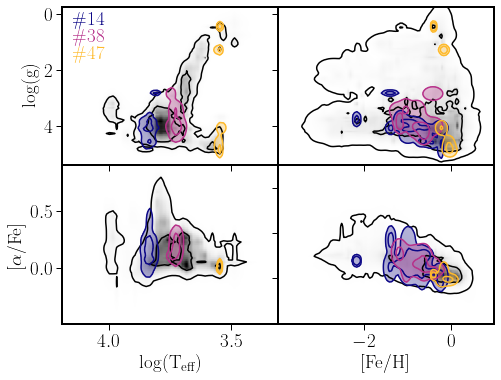

In [134]:
c_cut=0.85
cmap='plasma'
#cmap='Spectral'
n_fibs=np.array((14,38,47))
fig=plt.figure(figsize=(7.5,5.5))
left=[0.1,0.5]
width=0.4
axLS=[]
for x in left:
    for y in left:
#        print(x,y)
        axLS.append(fig.add_axes([x+0.03, y+0.05, width, width]))

axLS[1].set_xticklabels([])
axLS[2].set_yticklabels([])
axLS[3].set_xticklabels([])
axLS[3].set_yticklabels([])
#conts=[0.95,0.65,0.40,0.0]
conts=[0.85,0.40,0.0]


hdu_now=rsp_hdu['PDF_TEFF_LOGG']
xlabel=r'log(T$_{\rm eff}$)'
ylabel=r'log(g)'
PDF_plot_cl(ax=axLS[1],hdu_now=hdu_now,xlabel='',ylabel=ylabel,\
             n_fibs=n_fibs,\
             conts=conts,cmap=cmap,c_cut=c_cut)  

hdu_now=rsp_hdu['PDF_TEFF_ALPHAM']
xlabel=r'log(T$_{\rm eff}$)'
ylabel=r'[$\alpha$/Fe]'
PDF_plot_cl(ax=axLS[0],hdu_now=hdu_now,xlabel=xlabel,ylabel=ylabel,\
             n_fibs=n_fibs,\
             conts=conts,cmap=cmap,c_cut=c_cut)  




hdu_now=rsp_hdu['PDF_MET_ALPHAM']
xlabel=r'[Fe/H]'
ylabel=r'[$\alpha$/Fe]'

PDF_plot_cl(ax=axLS[2],hdu_now=hdu_now,xlabel=xlabel,ylabel='',\
             n_fibs=n_fibs,\
             conts=conts,cmap=cmap,c_cut=c_cut)   

hdu_now=rsp_hdu['PDF_MET_LOGG']
xlabel=r'[Fe/H]'
ylabel=r'log(g)'


PDF_plot_cl(ax=axLS[3],hdu_now=hdu_now,xlabel='',ylabel='',\
             n_fibs=n_fibs,\
             conts=conts,cmap=cmap,c_cut=c_cut)   

axLS[0].set_xlim(4.19,3.31)
axLS[1].set_xlim(4.19,3.31)

axLS[0].set_ylim(-0.49,0.9)
axLS[3].set_ylim(-0.49,0.9)



axLS[2].set_xlim(-3.99,0.99)
axLS[3].set_xlim(-3.99,0.99)

axLS[1].set_ylim(5.4,-0.25)
axLS[3].set_ylim(5.4,-0.25)

color='deepskyblue'
ecolor='blue'
size=100


cmap_class = mpl.colormaps[cmap]
colors = cmap_class(np.linspace(0, c_cut, len(n_fibs)))
for I,n_fib in enumerate(n_fibs):
    axLS[1].text(4.15,0.4+0.6*I,f'\#{n_fib}',color=colors[I])

#handles, labels = axLS[1].get_legend_handles_labels()
#axLS[1].legend(handles, labels)#,loc=(4.15,0.4),frameon=True,\
              #handlelength=1.5,ncol=1,columnspacing=0.15)#,title=z_label)


#axLS[1].scatter(tab_in['TEFF'][n_fib],tab_in['LOGG'][n_fib],\
#                color=color,zorder=1000,marker='*',s=size,edgecolor=ecolor)
#axLS[0].scatter(tab_in['TEFF'][n_fib],tab_in['ALPHAM'][n_fib],\
#                color=color,zorder=1000,marker='*',s=size,edgecolor=ecolor)
#axLS[2].scatter(tab_in['MET'][n_fib],tab_in['ALPHAM'][n_fib],\
#                color=color,zorder=1000,marker='*',s=size,edgecolor=ecolor)
#axLS[3].scatter(tab_in['MET'][n_fib],tab_in['LOGG'][n_fib],\
#                color=color,zorder=1000,marker='*',s=size,edgecolor=ecolor)

#axLS[1].scatter(tab_in['TEFF'],tab_in['LOGG'],color='green')
print(tab_in['TEFF'][n_fib],tab_in['LOGG'][n_fib])
figname=f'PDF_rsp_few'
fig.tight_layout()
fig.savefig('figs/'+figname+".pdf", transparent=False, facecolor='white', edgecolor='white')#.pdf")

In [135]:
#
# Compare simulations input vs. ouput
#


In [136]:
in_file="/disk-a/sanchez/LVM/LVM/ver_231113/mstar-stlib-cl-342.fits.gz"
hdu_in=fits.open(in_file)
tab_in=Table(hdu_in[1].data)
#tab_in['TEFF']=np.log10(tab_in['TEFF'])
tab_in.columns

DIR_IN="input_sim/"
out_file_coeffs=f'{DIR_IN}/coeffs_sim_st342_00006109_1700_5_100.0_0.0'
tab_coeffs_all_in=read_coeffs_RSP(coeffs_file=out_file_coeffs)


DIR='output_sim/'
#label="MaStar_test"
label="00006109_cl_SN1_342_1700_5_100.0"
out_file_coeffs=f'{DIR}/{label}.coeffs.txt'
output_path='figs/'
outfile='test.pdf'
tab_el=read_tab_EL('_legacy/emission_lines_long_list.LVM')
tab_coeffs_all=read_coeffs_RSP(coeffs_file=out_file_coeffs)

rsp_file='/disk-a/sanchez/LVM/LVM/ver_231113/mstar-stlib-cl-36.fits.gz'
rsp_hdu=fits.open(rsp_file)
rsp_hdu.info()


Filename: /disk-a/sanchez/LVM/LVM/ver_231113/mstar-stlib-cl-36.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SPECTRA       1 PrimaryHDU      13   (6351, 36)   float32   
  1  PARAMETERS    1 BinTableHDU     29   36R x 10C   [D, E, E, E, E, E, E, E, E, E]   
  2  ERROR         1 ImageHDU        14   (6351, 36)   float32   
  3  ORG_PARAM     1 BinTableHDU     31   1235R x 11C   [K, E, E, E, E, E, E, E, E, E, J]   
  4  PDF_TEFF_LOGG    1 ImageHDU        17   (100, 100, 36)   float64   
  5  PDF_TEFF_MET    1 ImageHDU        17   (100, 100, 36)   float64   
  6  PDF_TEFF_ALPHAM    1 ImageHDU        17   (100, 100, 36)   float64   
  7  PDF_MET_ALPHAM    1 ImageHDU        17   (100, 100, 36)   float64   
  8  PDF_MET_LOGG    1 ImageHDU        17   (100, 100, 36)   float64   
  9  PDF_LOGG_MET    1 ImageHDU        17   (100, 100, 36)   float64   


In [137]:
print(len(tab_coeffs_all))
print(len(tab_coeffs_all_in))
print(tab_in.columns)
hdu_in.info()

61200
581400
<TableColumns names=('N_ST','TEFF','LOGG','MET','ALPHAM','FNORM','e_TEFF','e_LOGG','e_MET','e_ALPHAM')>
Filename: /disk-a/sanchez/LVM/LVM/ver_231113/mstar-stlib-cl-342.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SPECTRA       1 PrimaryHDU      13   (6351, 342)   float32   
  1  PARAMETERS    1 BinTableHDU     29   342R x 10C   ['D', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E']   
  2  ERROR         1 ImageHDU        14   (6351, 342)   float32   
  3  ORG_PARAM     1 BinTableHDU     31   1235R x 11C   [K, E, E, E, E, E, E, E, E, E, J]   
  4  PDF_TEFF_LOGG    1 ImageHDU        17   (100, 100, 342)   float64   
  5  PDF_TEFF_MET    1 ImageHDU        17   (100, 100, 342)   float64   
  6  PDF_TEFF_ALPHAM    1 ImageHDU        17   (100, 100, 342)   float64   
  7  PDF_MET_ALPHAM    1 ImageHDU        17   (100, 100, 342)   float64   
  8  PDF_MET_LOGG    1 ImageHDU        17   (100, 100, 342)   float64   
  9  PDF_LOGG_MET    1 ImageHDU        17 

61200
581400
0.1 0.1
0.1 0.5
0.5 0.1
0.5 0.5


<ipython-input-149-0092a131f044>:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


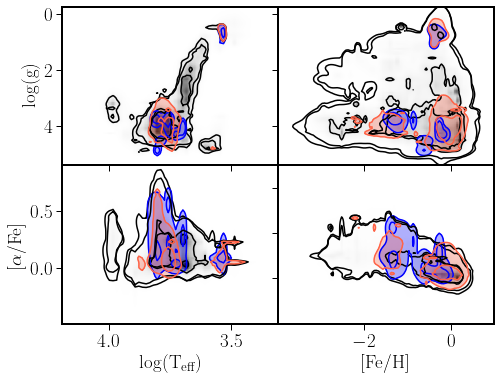

In [149]:
n_fib=50
tab_coeffs=tab_coeffs_all#[tab_coeffs_all['id_fib']==n_fib]
print(len(tab_coeffs))

tab_coeffs_in=tab_coeffs_all_in#[tab_coeffs_all_in['id_fib']==n_fib]
print(len(tab_coeffs_in))

color_in='blue'
color_out='tomato'

fig=plt.figure(figsize=(7.5,5.5))
left=[0.1,0.5]
width=0.4
axLS=[]
for x in left:
    for y in left:
        print(x,y)
        axLS.append(fig.add_axes([x+0.03, y+0.05, width, width]))

axLS[1].set_xticklabels([])
axLS[2].set_yticklabels([])
axLS[3].set_xticklabels([])
axLS[3].set_yticklabels([])
#conts=[0.95,0.65,0.40,0.0]
conts=[0.85,0.40,0.0]



hdu_now=hdu_in['PDF_TEFF_LOGG']
xlabel=r'log(T$_{\rm eff}$)'
ylabel=r'log(g)'
PDF_TEFF_LOGG_in = PDF_plot(ax=axLS[1],hdu_now=hdu_now,xlabel='',ylabel=ylabel,\
             n_fib=n_fib,tab_coeffs=tab_coeffs_in,\
             conts=conts,color_PDF=color_in)  

hdu_now=rsp_hdu['PDF_TEFF_LOGG']
xlabel=r'log(T$_{\rm eff}$)'
ylabel=r'log(g)'
PDF_TEFF_LOGG_out = PDF_plot(ax=axLS[1],hdu_now=hdu_now,xlabel='',ylabel=ylabel,\
             n_fib=n_fib,tab_coeffs=tab_coeffs,\
             conts=conts,color_PDF=color_out)  


hdu_now=hdu_in['PDF_TEFF_ALPHAM']
xlabel=r'log(T$_{\rm eff}$)'
ylabel=r'[$\alpha$/Fe]'
PDF_TEFF_ALPHAM_in = PDF_plot(ax=axLS[0],hdu_now=hdu_now,xlabel=xlabel,ylabel=ylabel,\
             n_fib=n_fib,tab_coeffs=tab_coeffs_in,\
             conts=conts,color_PDF=color_in)  

hdu_now=rsp_hdu['PDF_TEFF_ALPHAM']
xlabel=r'log(T$_{\rm eff}$)'
ylabel=r'[$\alpha$/Fe]'
PDF_TEFF_ALPHAM_out = PDF_plot(ax=axLS[0],hdu_now=hdu_now,xlabel=xlabel,ylabel=ylabel,\
             n_fib=n_fib,tab_coeffs=tab_coeffs,\
             conts=conts,color_PDF=color_out)  



hdu_now=hdu_in['PDF_MET_ALPHAM']
xlabel=r'[Fe/H]'
ylabel=r'[$\alpha$/Fe]'

PDF_MET_ALPHAM_in = PDF_plot(ax=axLS[2],hdu_now=hdu_now,xlabel=xlabel,ylabel='',\
             n_fib=n_fib,tab_coeffs=tab_coeffs_in,\
             conts=conts,color_PDF=color_in)  

hdu_now=rsp_hdu['PDF_MET_ALPHAM']
xlabel=r'[Fe/H]'
ylabel=r'[$\alpha$/Fe]'

PDF_MET_ALPHAM_out = PDF_plot(ax=axLS[2],hdu_now=hdu_now,xlabel=xlabel,ylabel='',\
             n_fib=n_fib,tab_coeffs=tab_coeffs,\
             conts=conts,color_PDF=color_out)  


hdu_now=hdu_in['PDF_MET_LOGG']
xlabel=r'[Fe/H]'
ylabel=r'log(g)'

PDF_MET_LOGG_in = PDF_plot(ax=axLS[3],hdu_now=hdu_now,xlabel='',ylabel='',\
             n_fib=n_fib,tab_coeffs=tab_coeffs_in,\
             conts=conts,color_PDF=color_in)  

hdu_now=rsp_hdu['PDF_MET_LOGG']
xlabel=r'[Fe/H]'
ylabel=r'log(g)'

PDF_MET_LOGG_out = PDF_plot(ax=axLS[3],hdu_now=hdu_now,xlabel='',ylabel='',\
             n_fib=n_fib,tab_coeffs=tab_coeffs,\
             conts=conts,color_PDF=color_out)  

axLS[0].set_xlim(4.19,3.31)
axLS[1].set_xlim(4.19,3.31)

axLS[0].set_ylim(-0.49,0.9)
axLS[3].set_ylim(-0.49,0.9)



axLS[2].set_xlim(-3.99,0.99)
axLS[3].set_xlim(-3.99,0.99)

axLS[1].set_ylim(5.4,-0.25)
axLS[3].set_ylim(5.4,-0.25)

color='deepskyblue'
ecolor='blue'
size=100

#axLS[1].text(4.15,0.4,f'\#{n_fib}',color='tomato')
#axLS[1].scatter(tab_in['TEFF'][n_fib],tab_in['LOGG'][n_fib],\
#                color=color,zorder=1000,marker='*',s=size,edgecolor=ecolor)
#axLS[0].scatter(tab_in['TEFF'][n_fib],tab_in['ALPHAM'][n_fib],\
#                color=color,zorder=1000,marker='*',s=size,edgecolor=ecolor)
#axLS[2].scatter(tab_in['MET'][n_fib],tab_in['ALPHAM'][n_fib],\
#                color=color,zorder=1000,marker='*',s=size,edgecolor=ecolor)
#axLS[3].scatter(tab_in['MET'][n_fib],tab_in['LOGG'][n_fib],\
#                color=color,zorder=1000,marker='*',s=size,edgecolor=ecolor)

#axLS[1].scatter(tab_in['TEFF'],tab_in['LOGG'],color='green')
#print(tab_in['TEFF'][n_fib],tab_in['LOGG'][n_fib])
figname=f'PDF_rsp_sim_{n_rsp}_{n_fib}'
fig.tight_layout()
fig.savefig('figs/rsp/'+figname+".pdf", transparent=False, facecolor='white', edgecolor='white')#.pdf")

1.079003989726716e-166 2.5698687434769333e-05
0.0017731247584369025
1.0


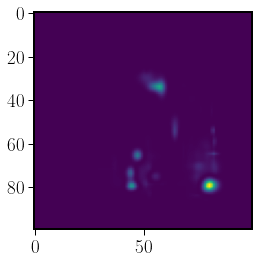

In [75]:
D_PDF_MET_LOGG=(PDF_MET_LOGG_out-PDF_MET_LOGG_in)**2#/(PDF_MET_LOGG_out.shape[0]*PDF_MET_LOGG_out.shape[1])
print(np.min(D_PDF_MET_LOGG),np.max(D_PDF_MET_LOGG))
plt.imshow(D_PDF_MET_LOGG)#,vmin=,vmax=0.001)
print(np.sum(D_PDF_MET_LOGG))
print(np.sum(PDF_MET_LOGG_out))
#print(np.sum(PDF_MET_LOGG_out),np.sum(PDF_MET_LOGG_in),np.min(PDF_MET_LOGG_out-PDF_MET_LOGG_in),np.max((PDF_MET_LOGG_out-PDF_MET_LOGG_in)))

In [85]:
a_PDF_TEFF_LOGG_in = []
a_PDF_TEFF_ALPHAM_in = []
a_PDF_MET_ALPHAM_in = []
a_PDF_MET_LOGG_in = []

a_PDF_TEFF_LOGG_out = []
a_PDF_TEFF_ALPHAM_out = []
a_PDF_MET_ALPHAM_out = []
a_PDF_MET_LOGG_out = []

n_fib_print=100
n_fib_all = np.unique(tab_coeffs_all['id_fib'])
for n_fib in n_fib_all:
    if (int(n_fib/n_fib_print) == (n_fib/n_fib_print)):
        print(f'{n_fib}/{np.max(n_fib_all)}...',end='')
    tab_coeffs=tab_coeffs_all#[tab_coeffs_all['id_fib']==n_fib]
    #print(len(tab_coeffs))
    tab_coeffs_in=tab_coeffs_all_in
    #[tab_coeffs_all_in['id_fib']==n_fib]
    #print(len(tab_coeffs_in))
    color_in='blue'
    color_out='tomato'
    conts=[0.85,0.40,0.0]
    hdu_now=hdu_in['PDF_TEFF_LOGG']
    xlabel=r'log(T$_{\rm eff}$)'
    ylabel=r'log(g)'
    PDF_TEFF_LOGG_in = PDF_get(ax=axLS[1],hdu_now=hdu_now,xlabel='',ylabel=ylabel,\
             n_fib=n_fib,tab_coeffs=tab_coeffs_in,\
             conts=conts,color_PDF=color_in)  

    hdu_now=rsp_hdu['PDF_TEFF_LOGG']
    xlabel=r'log(T$_{\rm eff}$)'
    ylabel=r'log(g)'
    PDF_TEFF_LOGG_out = PDF_get(ax=axLS[1],hdu_now=hdu_now,xlabel='',ylabel=ylabel,\
             n_fib=n_fib,tab_coeffs=tab_coeffs,\
             conts=conts,color_PDF=color_out)  


    hdu_now=hdu_in['PDF_TEFF_ALPHAM']
    xlabel=r'log(T$_{\rm eff}$)'
    ylabel=r'[$\alpha$/Fe]'
    PDF_TEFF_ALPHAM_in = PDF_get(ax=axLS[0],hdu_now=hdu_now,\
                                      xlabel=xlabel,ylabel=ylabel,\
             n_fib=n_fib,tab_coeffs=tab_coeffs_in,\
             conts=conts,color_PDF=color_in)  

    hdu_now=rsp_hdu['PDF_TEFF_ALPHAM']
    xlabel=r'log(T$_{\rm eff}$)'
    ylabel=r'[$\alpha$/Fe]'
    PDF_TEFF_ALPHAM_out = PDF_get(ax=axLS[0],\
                                  hdu_now=hdu_now,xlabel=xlabel,ylabel=ylabel,\
             n_fib=n_fib,tab_coeffs=tab_coeffs,\
             conts=conts,color_PDF=color_out)  


    hdu_now=hdu_in['PDF_MET_ALPHAM']
    xlabel=r'[Fe/H]'
    ylabel=r'[$\alpha$/Fe]'

    PDF_MET_ALPHAM_in = PDF_get(ax=axLS[2],hdu_now=hdu_now,xlabel=xlabel,ylabel='',\
             n_fib=n_fib,tab_coeffs=tab_coeffs_in,\
             conts=conts,color_PDF=color_in)  

    hdu_now=rsp_hdu['PDF_MET_ALPHAM']
    xlabel=r'[Fe/H]'
    ylabel=r'[$\alpha$/Fe]'

    PDF_MET_ALPHAM_out = PDF_get(ax=axLS[2],hdu_now=hdu_now,xlabel=xlabel,ylabel='',\
             n_fib=n_fib,tab_coeffs=tab_coeffs,\
             conts=conts,color_PDF=color_out)  


    hdu_now=hdu_in['PDF_MET_LOGG']
    xlabel=r'[Fe/H]'
    ylabel=r'log(g)'

    PDF_MET_LOGG_in = PDF_get(ax=axLS[3],hdu_now=hdu_now,xlabel='',ylabel='',\
             n_fib=n_fib,tab_coeffs=tab_coeffs_in,\
             conts=conts,color_PDF=color_in)  

    hdu_now=rsp_hdu['PDF_MET_LOGG']
    xlabel=r'[Fe/H]'
    ylabel=r'log(g)'

    PDF_MET_LOGG_out = PDF_get(ax=axLS[3],hdu_now=hdu_now,xlabel='',ylabel='',\
             n_fib=n_fib,tab_coeffs=tab_coeffs,\
             conts=conts,color_PDF=color_out)  

    a_PDF_TEFF_LOGG_in.append(PDF_TEFF_LOGG_in)
    a_PDF_TEFF_ALPHAM_in.append(PDF_TEFF_ALPHAM_in)
    a_PDF_MET_ALPHAM_in.append(PDF_MET_ALPHAM_in)
    a_PDF_MET_LOGG_in.append(PDF_MET_LOGG_in)

    a_PDF_TEFF_LOGG_out.append(PDF_TEFF_LOGG_out)
    a_PDF_TEFF_ALPHAM_out.append(PDF_TEFF_ALPHAM_out)
    a_PDF_MET_ALPHAM_out.append(PDF_MET_ALPHAM_out)
    a_PDF_MET_LOGG_out.append(PDF_MET_LOGG_out)
    if (int(n_fib/n_fib_print) == (n_fib/n_fib_print)):
        print(f'DONE; ')

a_PDF_TEFF_LOGG_in = np.array(a_PDF_TEFF_LOGG_in)
a_PDF_TEFF_ALPHAM_in = np.array(a_PDF_TEFF_ALPHAM_in)
a_PDF_MET_ALPHAM_in = np.array(a_PDF_MET_ALPHAM_in)
a_PDF_MET_LOGG_in = np.array(a_PDF_MET_LOGG_in)

a_PDF_TEFF_LOGG_out = np.array(a_PDF_TEFF_LOGG_out)
a_PDF_TEFF_ALPHAM_out = np.array(a_PDF_TEFF_ALPHAM_out)
a_PDF_MET_ALPHAM_out = np.array(a_PDF_MET_ALPHAM_out)
a_PDF_MET_LOGG_out = np.array(a_PDF_MET_LOGG_out)



0/1699...DONE; 
10/1699...DONE; 
20/1699...DONE; 
30/1699...DONE; 
40/1699...DONE; 
50/1699...DONE; 
60/1699...DONE; 
70/1699...DONE; 
80/1699...DONE; 
90/1699...DONE; 
100/1699...DONE; 
110/1699...DONE; 
120/1699...DONE; 
130/1699...DONE; 
140/1699...DONE; 
150/1699...DONE; 
160/1699...DONE; 
170/1699...DONE; 
180/1699...DONE; 
190/1699...DONE; 
200/1699...DONE; 
210/1699...DONE; 
220/1699...DONE; 
230/1699...DONE; 
240/1699...DONE; 
250/1699...DONE; 
260/1699...DONE; 
270/1699...DONE; 
280/1699...DONE; 
290/1699...DONE; 
300/1699...DONE; 
310/1699...DONE; 
320/1699...DONE; 
330/1699...DONE; 
340/1699...DONE; 
350/1699...DONE; 
360/1699...DONE; 
370/1699...DONE; 
380/1699...DONE; 
390/1699...DONE; 
400/1699...DONE; 
410/1699...DONE; 
420/1699...DONE; 
430/1699...DONE; 
440/1699...DONE; 
450/1699...DONE; 
460/1699...DONE; 
470/1699...DONE; 
480/1699...DONE; 
490/1699...DONE; 
500/1699...DONE; 
510/1699...DONE; 
520/1699...DONE; 
530/1699...DONE; 
540/1699...DONE; 
550/1699...DONE; 
560

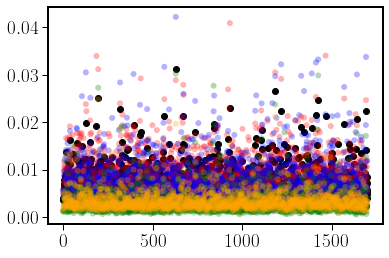

In [145]:
D_PDF_TEFF_LOGG = np.sum((a_PDF_TEFF_LOGG_out-a_PDF_TEFF_LOGG_in)**2,axis=(1,2))
D_PDF_TEFF_ALPHAM = np.sum((a_PDF_TEFF_ALPHAM_out-a_PDF_TEFF_ALPHAM_in)**2,axis=(1,2))
D_PDF_MET_ALPHAM = np.sum((a_PDF_MET_ALPHAM_out-a_PDF_MET_ALPHAM_in)**2,axis=(1,2))
D_PDF_MET_LOGG = np.sum((a_PDF_MET_LOGG_out-a_PDF_MET_LOGG_in)**2,axis=(1,2))

D_PDF = np.sqrt(D_PDF_TEFF_LOGG**2+D_PDF_TEFF_ALPHAM**2+D_PDF_MET_ALPHAM**2+D_PDF_MET_LOGG**2)/np.sqrt(4)


plt.scatter(n_fib_all,D_PDF, color='k')
plt.scatter(n_fib_all,D_PDF_TEFF_LOGG,color='red',alpha=0.3,edgecolor='None')
plt.scatter(n_fib_all,D_PDF_TEFF_ALPHAM,color='blue',alpha=0.3,edgecolor='None')
plt.scatter(n_fib_all,D_PDF_MET_ALPHAM,color='green',alpha=0.3,edgecolor='None')
plt.scatter(n_fib_all,D_PDF_MET_LOGG,color='orange',alpha=0.3,edgecolor='None')

                         

#a_PDF_TEFF_LOGG_in.shape
#plt.imshow(a_PDF_TEFF_LOGG_in[15],origin='lower')

(array([971., 549., 116.,  39.,  12.,   8.,   1.,   2.,   1.,   1.]),
 array([0.00082507, 0.00322458, 0.00562409, 0.00802359, 0.0104231 ,
        0.01282261, 0.01522212, 0.01762163, 0.02002114, 0.02242065,
        0.02482016]),
 <BarContainer object of 10 artists>)

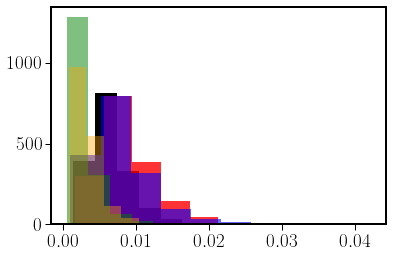

In [146]:


plt.hist(D_PDF, color='k')
plt.hist(D_PDF_TEFF_LOGG,color='red',alpha=0.8)
plt.hist(D_PDF_TEFF_ALPHAM,color='blue',alpha=0.6)
plt.hist(D_PDF_MET_ALPHAM,color='green',alpha=0.5)
plt.hist(D_PDF_MET_LOGG,color='orange',alpha=0.4)

                         
